In [1]:
import pandas as pd
from pathlib import Path
from datetime import date, timedelta
import pickle

with open('data/pie_data.pkl', 'rb') as file:
    pie_data = pickle.load(file)


### Данные

In [2]:
sd_df = pd.DataFrame(index= ['есть', 'нет'])
sd_df_c = pd.DataFrame(columns = pd.MultiIndex.from_arrays([[v for m in [(k, k) for k in pie_data.keys()] for v in m],
                                                            ['есть', 'нет']*len(pie_data)],
                                                            names=['Месяц', 'Сбережения']))
for month in pie_data:
    print(f'============= {month} =============')
    key = None
    for k in pie_data[month]:
        # search by the key word
        if 'какой-либо банковский, потребительский кредит или заём' in k:
            key = k
            break
        elif 'есть какие-либо кредиты' in k:
            key = k
            break
    
    if key is None:
        print('Не нашел вопроса')

    for k in pie_data[month][key].columns:
        if 'береж' in k[0]:
            category_key = k[0]
            break
    for k in pie_data[month][key][category_key].index:
        if 'нет' in k:
            row_key = k
            break
    print(f'Вопрос: {key}')
    print(f'Категория: {category_key}')
    print(f'Ответ: {row_key}')
        
    
    sd_df_c[month] = pie_data[month][key][category_key].copy(deep = True)
    sd_df[month] = pie_data[month][key][category_key].loc[row_key, :].copy(deep = True)

sd_df['2025-08'] = (sd_df['2025-07']+sd_df['2025-09'])/2
sd_df.to_excel('data/sd.xlsx')

============= 2020-09 =============
Вопрос: Сегодня у Вас лично или у других членов Вашей семьи есть какой-либо банковский, потребительский кредит или заём в микрофинансовой организации, по которому Вам ещё нужно выплачивать деньги, или кредитов, займов нет? Посмотрите на карточку и выберите все подходящие ответы.
 (Карточка, любое число ответов.)
Категория: Наличие сбережений
Ответ: ни у меня, ни у членов моей семьи нет кредита
============= 2020-10 =============
Вопрос: Сегодня у Вас лично или у других членов Вашей семьи есть какой-либо банковский, потребительский кредит или заём в микрофинансовой организации, по которому Вам ещё нужно выплачивать деньги, или кредитов, займов нет? Посмотрите на карточку и выберите все подходящие ответы.
 (Карточка, любое число ответов.)
Категория: Наличие сбережений
Ответ: ни у меня, ни у членов моей семьи нет кредита
============= 2020-11 =============
Вопрос: Сегодня у Вас лично или у других членов Вашей семьи, которые живут вместе с Вами, есть как

In [3]:

ns_df = pd.DataFrame(columns = pd.MultiIndex.from_arrays([[v for m in [(k, k) for k in pie_data.keys()] for v in m],
                                                            ['есть', 'нет']*len(pie_data)],
                                                            names=['Месяц', 'Сбережения']))
for month in pie_data:
    print(f'============= {month} =============')
    key = None
    for k in pie_data[month]:
        # search by the key word
        if 'месяц Вам удалось что-нибудь отложить' in k:
            key = k
            break
        elif 'отложить' in k:
            key = k
            break
    
    if key is None:
        print('Не нашел вопроса')

    for k in pie_data[month][key].columns:
        if 'береж' in k[0]:
            category_key = k[0]
            break

    print(f'Вопрос: {key}')
    print(f'Категория: {category_key}')

        
    
    ns_df[month] = pie_data[month][key][category_key].copy(deep = True)


ns_df['2025-08'] = (sd_df['2025-07']+sd_df['2025-09'])/2


============= 2020-09 =============
Вопрос: Скажите, пожалуйста, за последний месяц Вам удалось что-нибудь отложить после расходов на текущие нужды или не удалось? И если удалось, то больше, чем обычно, меньше или примерно столько же?
Категория: Наличие сбережений
============= 2020-10 =============
Вопрос: Скажите, пожалуйста, за последний месяц Вам удалось что-нибудь отложить после расходов на текущие нужды или не удалось? И если удалось, то больше, чем обычно, меньше или примерно столько же?
Категория: Наличие сбережений
============= 2020-11 =============
Вопрос: Скажите, пожалуйста, за последний месяц Вам удалось что-нибудь отложить после расходов на текущие нужды или не удалось? И если удалось, то больше, чем обычно, меньше или примерно столько же?
Категория: Наличие сбережений
============= 2020-12 =============
Вопрос: Скажите, пожалуйста, за последний месяц Вам удалось что-нибудь отложить после расходов на текущие нужды или не удалось? И если удалось, то больше, чем обычно, ме

KeyError: None

In [ ]:
pie_data['2023-02']

{'Посмотрите на карточку. Как, по Вашему мнению, в целом изменились цены на продукты питания, непродовольственные товары и на услуги за прошедший месяц? (Карточка, один ответ.)': Категория             Население в целом        Пол               Возраст  \
 Группа                             100%    мужчины    женщины  18–30 лет   
 выросли очень сильно          44.284294  39.250276  48.416290  39.756098   
 выросли умеренно              36.679920  38.588754  35.113122  41.219512   
 выросли незначительно          9.443340  10.804851   8.325792   8.780488   
 не изменились                  4.622266   5.622933   3.800905   7.560976   
 снизились                      0.298211   0.551268   0.090498   0.243902   
 затрудняюсь ответить           4.671968   5.181918   4.253394   2.439024   
 
 Категория                                                    Образование  \
 Группа                 31–45 лет  46–60 лет старше 60 лет ниже среднего*   
 выросли очень сильно   46.095238  44.117647     4

<Figure size 1400x900 with 0 Axes>

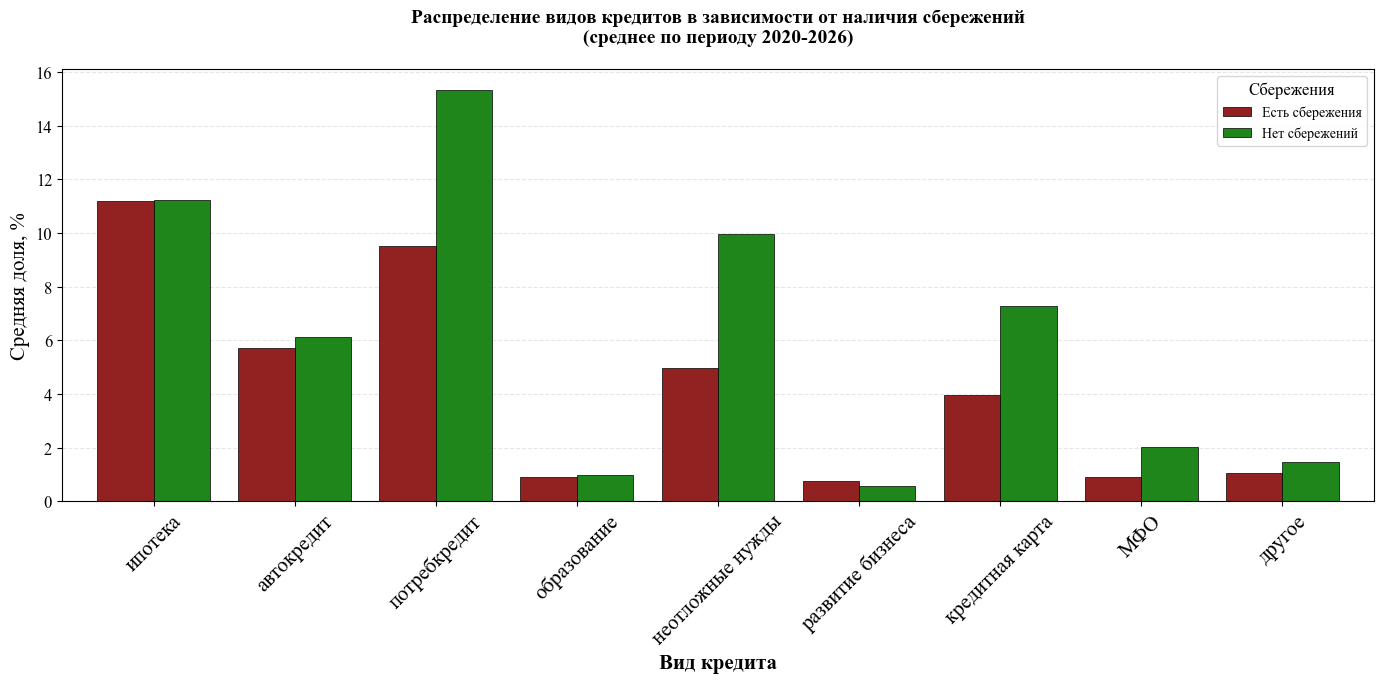

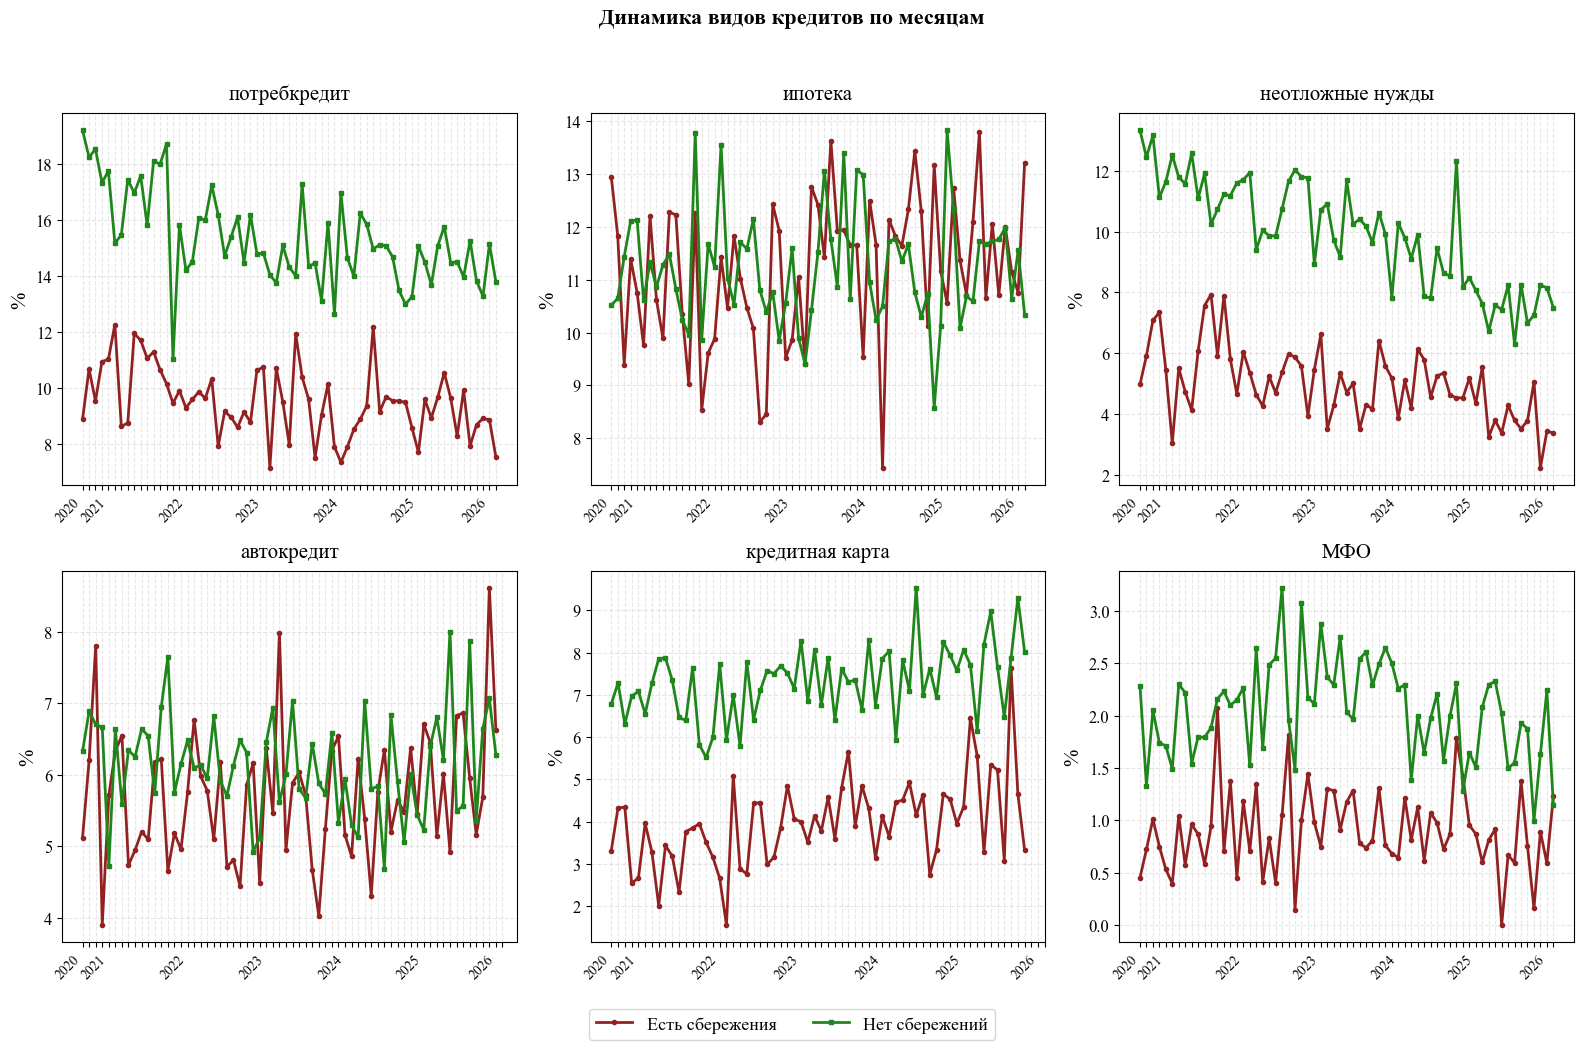

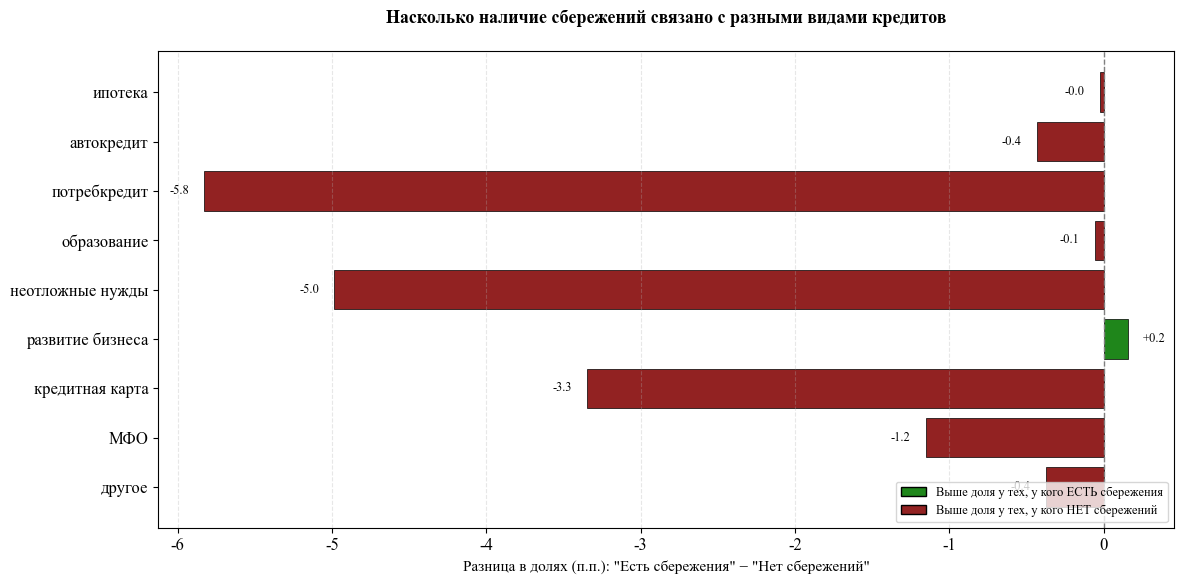

In [4]:

import matplotlib.pyplot as plt

from matplotlib.patches import Patch

# =====================================================
# 🔤 УСТАНОВКА ШРИФТА TIMES NEW ROMAN
# =====================================================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Для корректного отображения кириллицы (если нужно)
plt.rcParams['font.sans-serif'] = ['Times New Roman', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # Чтобы корректно отображались минусы

# =====================================================
# 🎨 ЦВЕТА
# =====================================================
nonhtm_color = "#922222"  # бордовый - есть сбережения
htm_color = "#1f861b"     # зелёный - нет сбережений

# =====================================================
# 📊 ГРАФИК 1: Группированная столбчатая диаграмма
# =====================================================
plt.figure(figsize=(14, 9))

df = sd_df_c.copy(deep=True).set_axis(['ипотека', 'автокредит', 'потребкредит', 'образование',
                                    'неотложные нужды', 'развитие бизнеса', 'кредитная карта', 'МФО', 'другое', 'нет кредита', 'затрудняюсь ответить'], axis = 0)
df_agg = df.T.groupby(level='Сбережения').mean()
credit_cols = [col for col in df_agg.columns if col not in ['нет кредита', 'затрудняюсь ответить']]
df_agg = df_agg[credit_cols].T

ax = df_agg.plot(kind='bar', width=0.8, figsize=(14, 7), 
                 color=[nonhtm_color, htm_color],
                 edgecolor='black', linewidth=0.5)

ax.set_xlabel('Вид кредита', fontsize=15, fontweight='bold')
ax.set_ylabel('Средняя доля, %', fontsize=15)
ax.set_title('Распределение видов кредитов в зависимости от наличия сбережений\n(среднее по периоду 2020-2026)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(['Есть сбережения', 'Нет сбережений'], title='Сбережения', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('grouped_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 📈 ГРАФИК 2: Динамика по месяцам (линейные графики)
# =====================================================
df = df.T.copy()
top_credits = df[credit_cols].mean().nlargest(6).index.tolist()

months = df.xs('есть', level='Сбережения').index.tolist()

def create_year_labels(months):
    labels = []
    prev_year = None
    for month in months:
        year = month.split('-')[0]
        if year != prev_year:
            labels.append(year)
            prev_year = year
        else:
            labels.append('')
    return labels

xsticks_labels = create_year_labels(months)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

handles, labels = None, None

for idx, credit in enumerate(top_credits):
    ax = axes[idx]
    
    line_yes = df.xs('есть', level='Сбережения')[credit]
    line_no = df.xs('нет', level='Сбережения')[credit]
    
    line1, = ax.plot(line_yes.index, line_yes.values, marker='o', markersize=3, 
            label='Есть сбережения', linewidth=2, color=nonhtm_color)
    line2, = ax.plot(line_no.index, line_no.values, marker='s', markersize=3, 
            label='Нет сбережений', linewidth=2, color=htm_color)
    
    if idx == 0:
        handles = [line1, line2]
        labels = ['Есть сбережения', 'Нет сбережений']
    
    ax.set_title(credit, fontsize=15, pad=10)
    ax.set_ylabel('%', fontsize=15)
    ax.set_xticks(range(len(months)))
    ax.set_xticklabels(xsticks_labels, rotation=45, ha='right', fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

# Общая легенда внизу
fig.legend(handles=handles, labels=labels, 
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=2, fontsize=13, frameon=True)

plt.suptitle('Динамика видов кредитов по месяцам', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('dynamics_top6.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 🎁 БОНУС: Сравнение разницы "есть - нет сбережений"
# =====================================================
diff = df_agg['есть'] - df_agg['нет']

plt.figure(figsize=(12, 6))
colors = [htm_color if x > 0 else nonhtm_color for x in diff.values]
bars = plt.barh(diff.index, diff.values, color=colors, edgecolor='black', linewidth=0.5)

plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Разница в долях (п.п.): "Есть сбережения" − "Нет сбережений"', fontsize=11)
plt.title('Насколько наличие сбережений связано с разными видами кредитов', 
          fontsize=13, fontweight='bold', pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    offset = 0.1 if width > 0 else -0.1
    ha = 'left' if width > 0 else 'right'
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, 
             f'{width:+.1f}', ha=ha, va='center', fontsize=9)

# Легенда для цветов
legend_elements = [
    Patch(facecolor=htm_color, edgecolor='black', label='Выше доля у тех, у кого ЕСТЬ сбережения'),
    Patch(facecolor=nonhtm_color, edgecolor='black', label='Выше доля у тех, у кого НЕТ сбережений')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('diff_bars.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
for k in pie_data['2023-02'].keys():
    print(k)

Посмотрите на карточку. Как, по Вашему мнению, в целом изменились цены на продукты питания, непродовольственные товары и на услуги за прошедший месяц? (Карточка, один ответ.)
Как, по Вашему мнению, в целом изменятся цены на продукты питания, непродовольственные товары и на услуги в следующем месяце? (Карточка, один ответ.)
Цены на разные продукты меняются по-разному. По Вашим наблюдениям, на какие основные продукты, товары и услуги, перечисленные на карточке, цены за последний месяц выросли очень сильно? (Карточка, любое число ответов.)
Как, по Вашему мнению, в целом менялись цены за прошедшие 12 месяцев (год), то есть с февраля 2022 года? (Карточка, один ответ.)
На сколько именно, по Вашему мнению, выросли цены за прошедшие 12 месяцев (год)?  (Вопрос не задавался тем, кто считает, что за прошедшие 12 месяцев цены не изменились или снижались, – отвечали 98% респондентов. Карточка, один ответ.)
Как, по Вашему мнению, в целом будут меняться цены в следующие 12 месяцев (год), то есть до ф

In [ ]:
sd_df_c.set_axis(['ипотека', 'автокредит', 'потребительский', 'образование',
                                    'неотложные нужды', 'развитие бизнеса', 'кредитка', 'мфо', 'другое', 'нет кредита', 'затрудняюсь ответить'], axis = 0)

Месяц                   2020-09               2020-10               2020-11  \
Сбережения                 есть        нет       есть        нет       есть   
ипотека               12.951807  10.518293  11.832612  10.649961   9.393064   
автокредит             5.120482   6.326220   6.204906   6.891151   7.803468   
потребительский        8.885542  19.207317  10.678211  18.245889   9.537572   
образование            0.301205   1.295732   0.432900   0.626468   1.156069   
неотложные нужды       4.969880  13.338415   5.916306  12.451057   7.080925   
развитие бизнеса       0.150602   0.609756   0.721501   0.626468   1.156069   
кредитка               3.313253   6.783537   4.329004   7.282694   4.335260   
мфо                    0.451807   2.286585   0.721501   1.331245   1.011561   
другое                 1.355422   1.600610   1.443001   1.801096   1.156069   
нет кредита           65.210843  50.609756  65.079365  51.527016  64.739884   
затрудняюсь ответить   1.204819   0.990854   0.721501   0.704777   0.433526   

Месяц                              2020-12               2021-01             \
Сбережения                  нет       есть        нет       есть        нет   
ипотека               11.435331  11.394303  12.112036  10.756972  12.133550   
автокредит             6.703470   3.898051   6.661620   5.710491   4.723127   
потребительский       18.533123  10.944528  17.335352  11.022576  17.752443   
образование            1.340694   0.299850   0.908403   0.265604   1.140065   
неотложные нужды      13.170347   7.346327  11.127933   5.444887  11.644951   
развитие бизнеса       0.473186   0.749625   0.605602   0.664011   0.488599   
кредитка               6.309148   2.548726   6.964421   2.656042   7.084691   
мфо                    2.050473   0.749625   1.741105   0.531208   1.710098   
другое                 1.498423   2.098951   1.211204   0.929615   0.814332   
нет кредита           51.813880  65.367316  53.368660  65.471448  52.850163   
затрудняюсь ответить   0.867508   0.899550   0.832702   0.929615   1.465798   

Месяц                 ...    2025-10               2025-11             \
Сбережения            ...       есть        нет       есть        нет   
ипотека               ...  10.705290  11.764706  12.006319  11.984733   
автокредит            ...   5.163728   5.370844   5.687204   6.641221   
потребительский       ...   7.934509  15.260017   8.688784  13.816794   
образование           ...   1.133501   1.705030   1.263823   1.221374   
неотложные нужды      ...   3.778338   6.990622   5.055292   7.251908   
развитие бизнеса      ...   1.133501   0.426257   0.157978   0.763359   
кредитка              ...   4.659950   9.292413   3.317536   8.015267   
мфо                   ...   0.755668   1.875533   0.157978   0.992366   
другое                ...   1.007557   1.619778   0.947867   1.526718   
нет кредита           ...  68.891688  57.459506  68.404423  59.465649   
затрудняюсь ответить  ...   0.755668   0.937766   1.263823   1.374046   

Месяц                   2025-12               2026-01               2026-02  \
Сбережения                 есть        нет       есть        нет       есть   
ипотека               11.144131  10.644911  10.756501  11.559140  13.210445   
автокредит             8.618128   7.070707   6.619385   6.272401        NaN   
потребительский        8.915305  13.286713   8.865248  15.143369   7.526882   
образование            1.040119   1.087801   0.945626   1.881720   1.689708   
неотложные нужды       2.228826   8.236208   3.427896   8.154122   3.379416   
развитие бизнеса       1.188707   0.543901   0.591017   0.896057   0.153610   
кредитка                    NaN        NaN        NaN        NaN        NaN   
мфо                    0.891530   1.631702   0.591017   2.240143   1.228879   
другое                 1.783061   1.398601   1.536643   1.164875   1.382488   
нет кредита           66.567608  60.062160  66.903073  59.856631  66.359447   
затрудняюсь ответить   1.188707   0.932401   1

In [6]:
import pandas as pd
import pickle
from datetime import datetime as dt

with open('data/monthly_data.pkl', 'rb') as file:
    monthly_data = pickle.load(file)
monthly_data

,key_rate,infl,target,dollar_m,m0,m1,m2,pi_e_ws,pi_e_wos,pi_e,...,credits_hh,deposits_hh,real_brent,rcwos_c,rc_c,real_dollar,real_rate,real_ruonia,log_credits_hh,log_deposits_hh
1947-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-01,16.5,6.64,4.0,80.343825,NaN,NaN,NaN,12.251634,13.659533,13.2692,...,39688369.0,66154141.0,0.195445,6.310930,6.435000,4138.344651,9.246062,9.080724,15.634817,16.145746
2025-12-01,16.0,5.59,4.0,78.401623,NaN,NaN,NaN,12.264706,14.617647,13.6944,...,39866533.0,66102246.0,0.188826,6.339776,6.464913,4031.902352,9.858888,9.896771,15.634658,16.140324
2026-01-01,16.0,6.00,4.0,77.214953,NaN,NaN,NaN,11.963918,15.203518,13.6630,...,40009537.0,69842053.0,0.197651,6.386615,6.512948,3948.488614,9.433962,9.144025,15.630836,16.187955
2026-02-01,15.5,5.91,4.0,76.927800,NaN,NaN,NaN,11.476190,14.192308,13.1497,...,40266688.0,68673041.0,0.211433,6.407205,6.538175,3931.632516,9.054858,8.889872,15.633377,16.167209


In [10]:
sdf = monthly_data.loc[monthly_data['s0'].notna()].loc[:,['s0', 's1']]/100
sdf['na'] = 1 - (sdf['s0']+sdf['s1'])

In [12]:
sdf.to_excel('data/sdf_excel.xlsx')

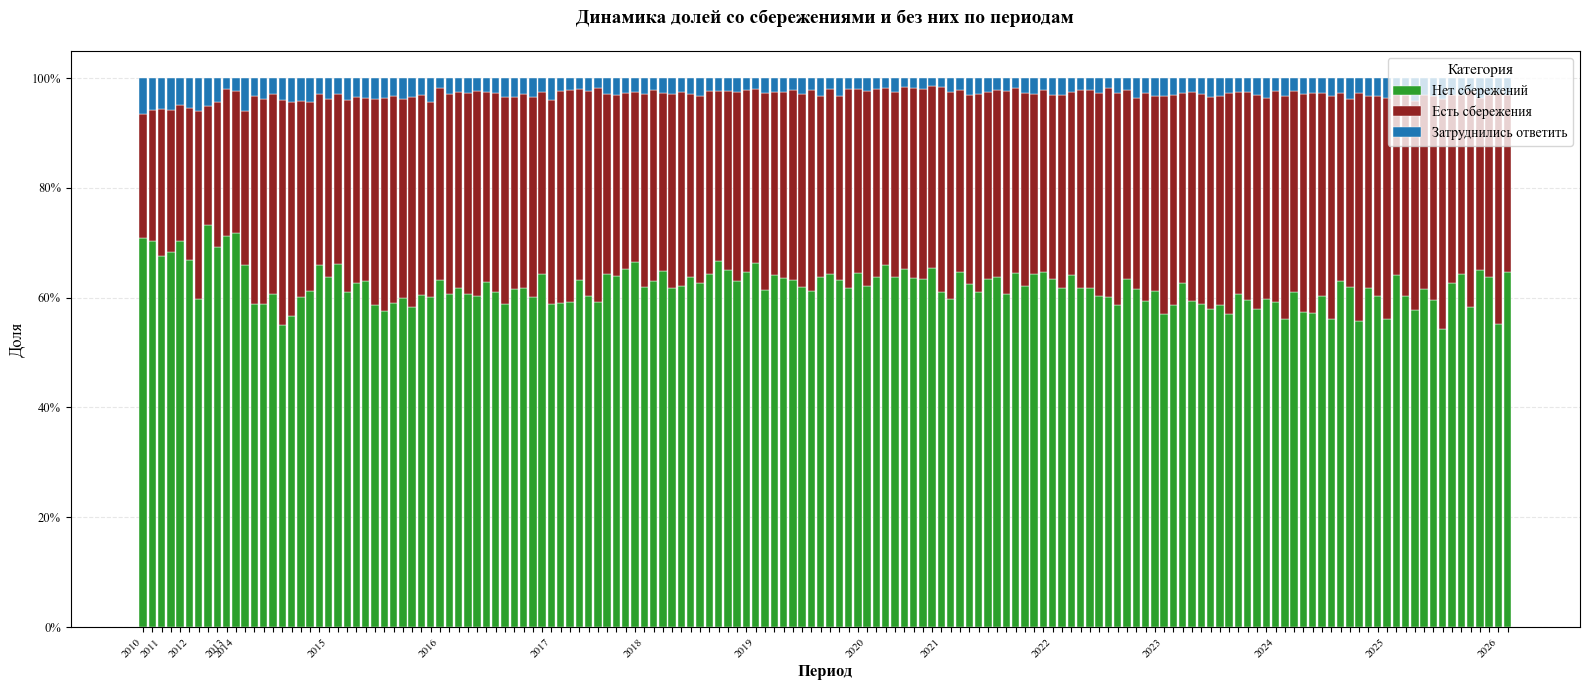

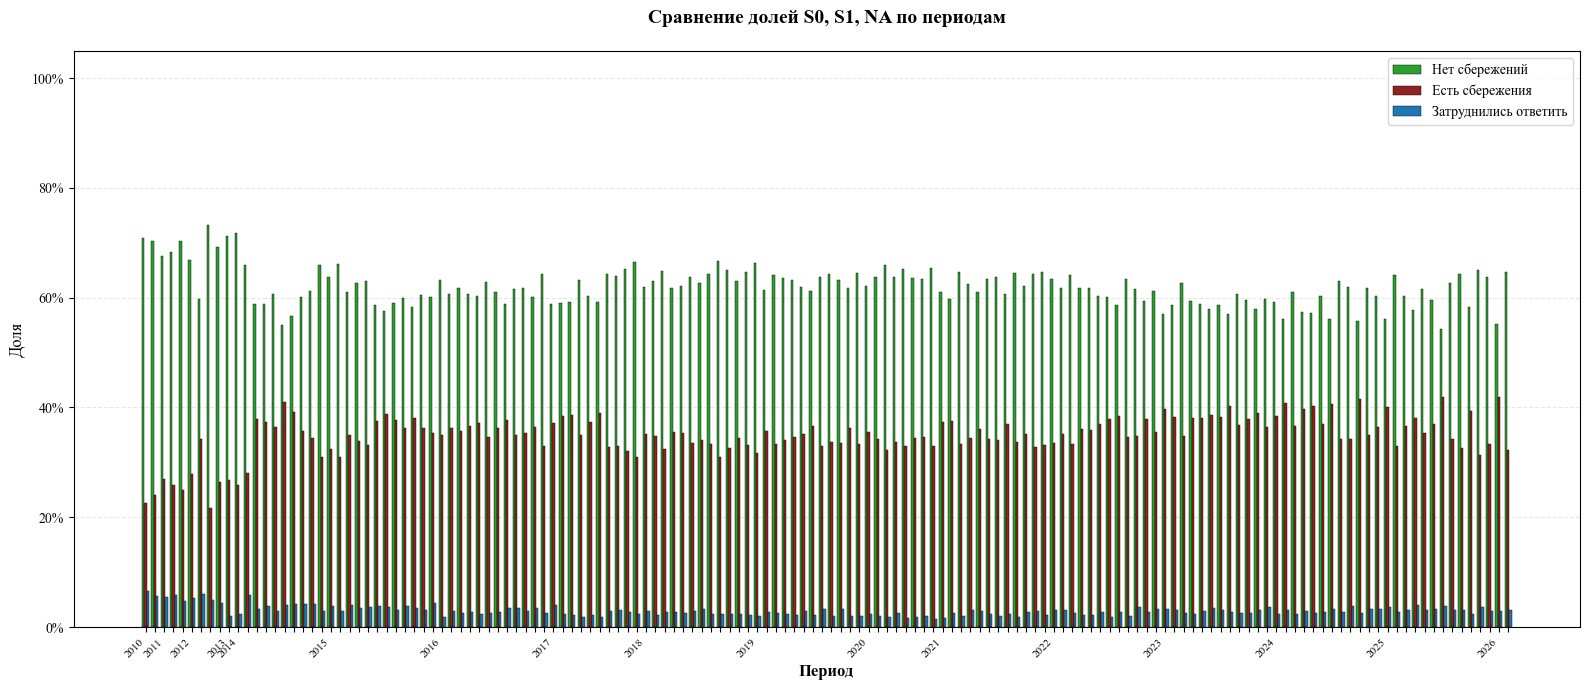

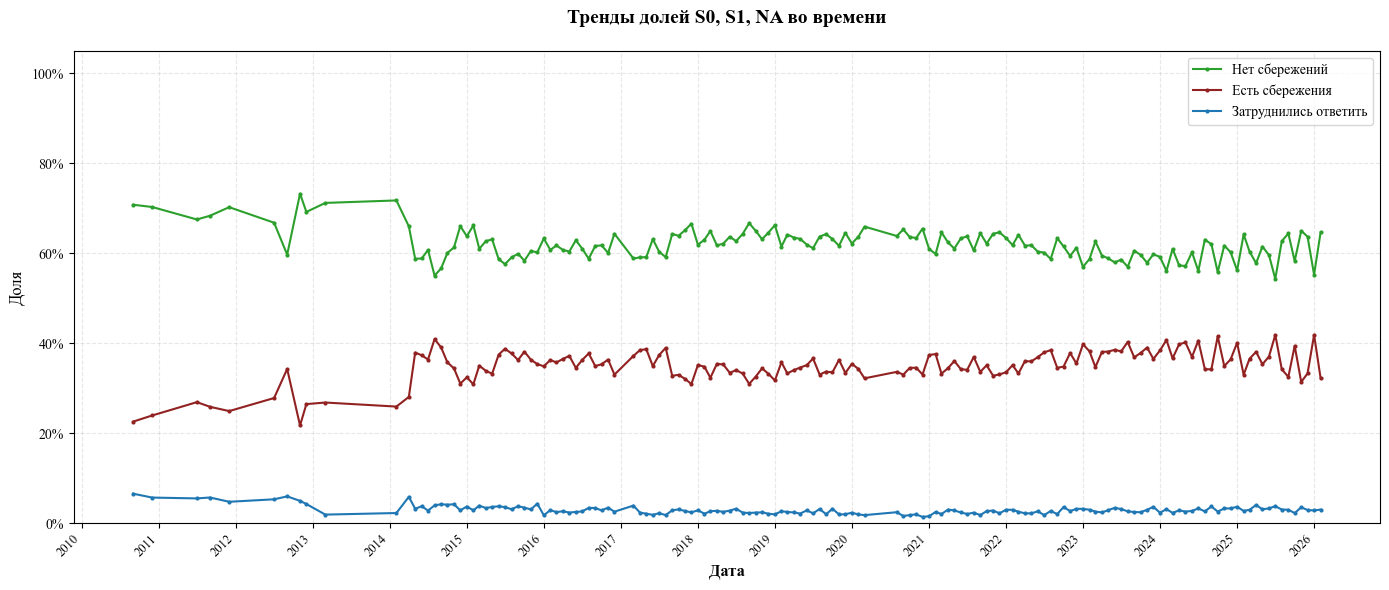

📊 Статистика по долям:
                       count      mean       std       min       25%  \
нет сбережений         148.0  0.620551  0.034345  0.543112  0.597607   
есть сбережения        148.0  0.349540  0.036410  0.217500  0.333125   
затруднились ответить  148.0  0.029909  0.009260  0.014378  0.024000   

                            50%       75%       max  
нет сбережений         0.617719  0.641070  0.732500  
есть сбережения        0.351338  0.373625  0.418812  
затруднились ответить  0.028500  0.033238  0.066000  

🔍 Последние 5 периодов:
            нет сбережений  есть сбережения  затруднились ответить
2025-10-01        0.582712         0.394436               0.022851
2025-11-01        0.650124         0.314144               0.035732
2025-12-01        0.637129         0.333168               0.029703
2026-01-01        0.552475         0.418812               0.028713
2026-02-01        0.646855         0.322437               0.030708

✅ Проверка: сумма по строкам (должна быть ~1

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.dates import DateFormatter, MonthLocator, YearLocator

# =====================================================
# 🔤 ШРИФТЫ И НАСТРОЙКИ
# =====================================================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

# =====================================================
# 📥 ЗАГРУЗКА ДАННЫХ
# =====================================================
df = pd.read_excel('data/sdf_excel.xlsx', index_col=0, parse_dates=True).set_axis(['нет сбережений', 'есть сбережения', 'затруднились ответить'], axis = 1)
df.index = pd.to_datetime(df.index)
df = df.sort_index()  # Сортируем по времени

# Категории и цвета
categories = ['нет сбережений', 'есть сбережения', 'затруднились ответить']
colors = {
    'нет сбережений': '#2ca02c',    # синий
    'есть сбережения': '#922222',    # зелёный
    'затруднились ответить': '#1f77b4'     # бордовый
}
labels = {
    'нет сбережений': 'Нет сбережений',    # синий
    'есть сбережения': 'Есть сбережения',    # зелёный
    'затруднились ответить': 'Затруднились ответить'
}

# =====================================================
# 📊 ГРАФИК 1: Стэкированные бары (доли в сумме = 1)
# =====================================================
fig, ax = plt.subplots(figsize=(16, 7))

# Для стэкинга: используем bar с параметром bottom
x = np.arange(len(df))
bottom = np.zeros(len(df))

for cat in categories:
    ax.bar(x, df[cat], bottom=bottom, label=labels[cat],
           color=colors[cat], edgecolor='white', linewidth=0.3)
    bottom += df[cat]

# Подписи осей и заголовок
ax.set_xlabel('Период', fontsize=12, fontweight='bold')
ax.set_ylabel('Доля', fontsize=12)
ax.set_title('Динамика долей со сбережениями и без них по периодам', 
             fontsize=14, fontweight='bold', pad=20)

# 🔹 Ось X: показываем годы при смене
years = df.index.year
xtick_labels = []
prev_year = None
for i, y in enumerate(years):
    if y != prev_year:
        xtick_labels.append(str(y))
        prev_year = y
    else:
        xtick_labels.append('')

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)

# 🔹 Ось Y: проценты
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([f'{int(p*100)}%' for p in np.arange(0, 1.1, 0.2)], fontsize=9)

# Сетка, легенда, лимиты
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(title='Категория', fontsize=10, title_fontsize=11, loc='upper right')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('sdf_stacked_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 📊 ГРАФИК 2: Группированные бары (если хотите сравнение)
# =====================================================
fig, ax = plt.subplots(figsize=(16, 7))

width = 0.25
x = np.arange(len(df))

for idx, cat in enumerate(categories):
    ax.bar(x + (idx - 1) * width, df[cat], width, label=labels[cat],
           color=colors[cat], edgecolor='black', linewidth=0.3)

ax.set_xlabel('Период', fontsize=12, fontweight='bold')
ax.set_ylabel('Доля', fontsize=12)
ax.set_title('Сравнение долей S0, S1, NA по периодам', 
             fontsize=14, fontweight='bold', pad=20)

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([f'{int(p*100)}%' for p in np.arange(0, 1.1, 0.2)])
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('sdf_grouped_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 📈 ГРАФИК 3: Линейный график (для трендов)
# =====================================================
fig, ax = plt.subplots(figsize=(14, 6))

for cat in categories:
    ax.plot(df.index, df[cat], marker='o', markersize=2,
            label=labels[cat], color=colors[cat], linewidth=1.5)

ax.set_xlabel('Дата', fontsize=12, fontweight='bold')
ax.set_ylabel('Доля', fontsize=12)
ax.set_title('Тренды долей S0, S1, NA во времени', 
             fontsize=14, fontweight='bold', pad=20)

# Форматирование дат на оси X
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([f'{int(p*100)}%' for p in np.arange(0, 1.1, 0.2)])
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('sdf_lines.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 🎁 БОНУС: Статистика по категориям
# =====================================================
print("📊 Статистика по долям:")
print(df[categories].describe().T)

print("\n🔍 Последние 5 периодов:")
print(df[categories].tail())

print("\n✅ Проверка: сумма по строкам (должна быть ~1.0):")
print(df[categories].sum(axis=1).tail())